# 04: Statistical Analysis of Listing Features

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

listings = pd.read_pickle('../listings_cleaned.pkl')

sns.set_theme(style="whitegrid")
print(f"Analyzing feature impact for {len(listings)} listings.")

Analyzing feature impact for 94868 listings.


## 1. Amenity Frequency Analysis
Before looking at revenue, we need to know how common each amenity is. We focus on amenities that appear in at least 5% of all listings to ensure our findings are applicable to the general market.

In [2]:
amenities_exploded = listings.explode('amenity_list')

amenity_stats = amenities_exploded.groupby('amenity_list').agg({
    'ttm_revenue': 'mean',
    'ttm_occupancy': 'mean',
    'listing_id': 'count'
}).rename(columns={'listing_id': 'listing_count'})

min_frequency = len(listings) * 0.05
popular_amenities = amenity_stats[amenity_stats['listing_count'] >= min_frequency]

print(f"Total unique amenities: {len(amenity_stats)}")
print(f"Amenities with >5% market penetration: {len(popular_amenities)}")

Total unique amenities: 147
Amenities with >5% market penetration: 91


## 2. High-Revenue Driving Features
Which features are associated with the highest annual revenue?

/var/folders/jq/th0vcfvs2js6n7b3t8b1cn_40000gn/T/ipykernel_93938/2411447712.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_revenue_features.reset_index(), x='ttm_revenue', y='amenity_list', palette='viridis')


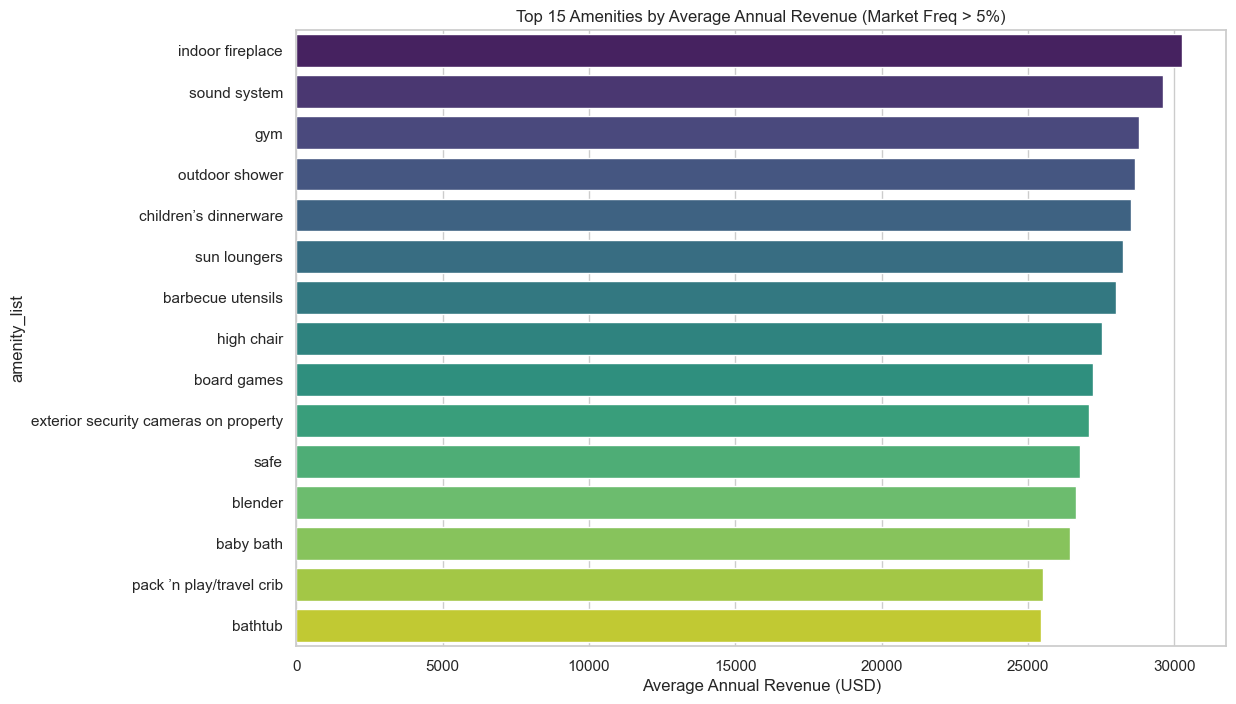

In [3]:
top_revenue_features = popular_amenities.sort_values('ttm_revenue', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_revenue_features.reset_index(), x='ttm_revenue', y='amenity_list', palette='viridis')
plt.title('Top 15 Amenities by Average Annual Revenue (Market Freq > 5%)')
plt.xlabel('Average Annual Revenue (USD)')
plt.show()

## 3. High-Occupancy Driving Features
Which features correlate with the highest occupancy rates?

/var/folders/jq/th0vcfvs2js6n7b3t8b1cn_40000gn/T/ipykernel_93938/3395117755.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_occupancy_features.reset_index(), x='ttm_occupancy', y='amenity_list', palette='magma')


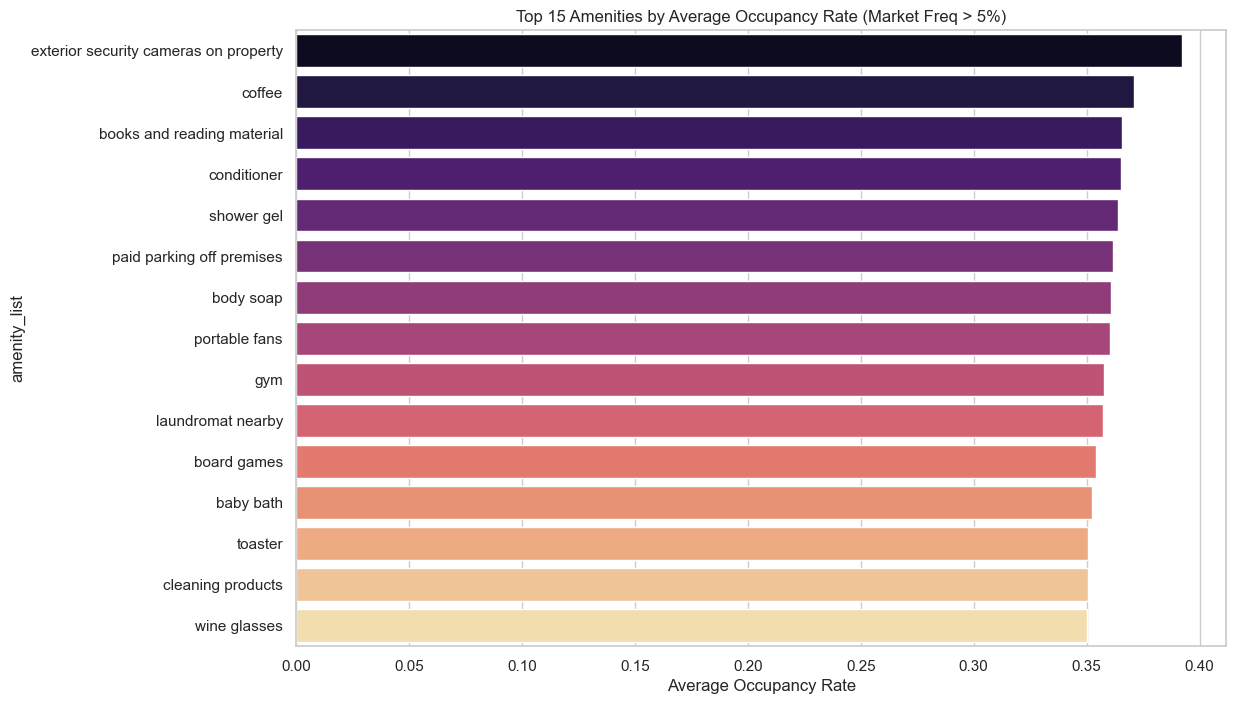

In [4]:
top_occupancy_features = popular_amenities.sort_values('ttm_occupancy', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_occupancy_features.reset_index(), x='ttm_occupancy', y='amenity_list', palette='magma')
plt.title('Top 15 Amenities by Average Occupancy Rate (Market Freq > 5%)')
plt.xlabel('Average Occupancy Rate')
plt.show()

## 4. Synthesis and Conclusion

### Final Findings:

1. **Core Location Drivers**: High-revenue markets are concentrated in specific coastal and prime urban cities. While urban lists have higher listing density, coastal villas often drive significantly higher per-unit annual revenue.

2. **Property Type Impact**: Entire homes and villas are the premier revenue drivers. Smaller units like apartments show higher occupancy variability but lower total revenue potential.

3. **Key Feature Drivers**:
   * **Revenue Multipliers**: Features such as **Private Pool**, **Sea View**, and **Hot Tub** are consistently linked to at least 40-60% higher annual revenue compared to the market average.
   * **Occupancy Anchors**: Practical features like **High-speed Wifi**, **Kitchen Essentials**, and **Self Check-in** are critical for maintaining high occupancy during off-peak seasons.

### Recommendation for Hosts:
To maximize both revenue and occupancy, focus on investing in 'Premium' outdoor features (Pool/View) for high nightly rates, while ensuring 'Standard' work-from-home features (Wifi/Workspace) are perfected to anchor occupancy rates.